# Exploratory Data Analysis of Palmer Penguins
## Week 2 submission
This analysis uses Pandas, Matplotlib and Seaborn to examine size distributions, species differences, relationships and unusual observations. All results are descriptive, not causal.

Questions: How is the sample composed? How does body mass vary by species and sex? Do pooled correlations hold within species? Are island and species separable? Which measurements warrant review?

Source: https://allisonhorst.github.io/palmerpenguins/

CSV: https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv

The supplied snapshot contains 344 records and 8 columns. Data collected by Kristen Gorman and Palmer Station LTER during 2007–2009; data license CC0. Retrieved 10 September 2026. The CSV was extracted from the source's line-numbered web representation after direct download timed out; all 345 lines including the header were recovered in source order.

In [1]:
from pathlib import Path
import hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if hasattr(value, 'to_string') else value)
ROOT = Path.cwd()
if not (ROOT / 'data/penguins.csv').exists():
    raise FileNotFoundError('Run from the extracted Week2_EDA folder.')
for folder in ['figures', 'tables']:
    (ROOT / folder).mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
ORDER = ['Adelie', 'Chinstrap', 'Gentoo']
COLORS = dict(zip(ORDER, ['#287D8E', '#C06A32', '#74529B']))
NUM = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
LABELS = ['Bill length (mm)', 'Bill depth (mm)', 'Flipper length (mm)', 'Body mass (g)']
df = pd.read_csv(ROOT / 'data/penguins.csv', na_values=['NA'])
def savefig(name):
    plt.tight_layout()
    plt.savefig(ROOT / 'figures' / f'{name}.png', dpi=180, bbox_inches='tight')
    plt.show()
    plt.close()
print('Shape:', df.shape)
print('SHA256:', hashlib.sha256((ROOT / 'data/penguins.csv').read_bytes()).hexdigest())
display(df.head())
df.info()

Shape: (344, 8)
SHA256: f204db2c753b0937caac3cb35258562c14f073e4bbc76be24b4c51ce22767a93
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 1 Data quality and analysis populations
Retain missing values in the source. Use only the columns required by each analysis to determine eligibility; do not impute sex or measured body size. This avoids manufactured correlations and preserves categorical counts.

In [2]:
quality = pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(),
                        'missing_pct': df.isna().mean() * 100})
quality.to_csv(ROOT / 'tables/data_quality.csv')
display(quality)
print('Exact duplicate rows:', df.duplicated().sum())
print('Nonpositive measurements:', int((df[NUM] <= 0).sum().sum()))
for col in ['species', 'island', 'sex', 'year']:
    print(col, df[col].dropna().unique())
assert df.shape == (344, 8)
assert df['species'].isin(ORDER).all()
assert df['island'].isin(['Biscoe', 'Dream', 'Torgersen']).all()
assert df['sex'].dropna().isin(['female', 'male']).all()
assert df['year'].isin([2007, 2008, 2009]).all()
assert (df[NUM].dropna() > 0).all().all()
measurements = df.dropna(subset=NUM).copy()
sex_data = df.dropna(subset=['sex', 'body_mass_g']).copy()
print('All records:', len(df), '| complete measurements:', len(measurements),
      '| sex and mass observed:', len(sex_data))
print('Missing sex by species:')
display(df.assign(missing_sex=df.sex.isna()).groupby('species').missing_sex.agg(['sum', 'mean']))

Exact duplicate rows: 0
Nonpositive measurements: 0
species ['Adelie' 'Gentoo' 'Chinstrap']
island ['Torgersen' 'Biscoe' 'Dream']
sex ['male' 'female']
year [2007 2008 2009]
All records: 344 | complete measurements: 342 | sex and mass observed: 333
Missing sex by species:


,dtype,missing,missing_pct
species,object,0,0.000000
island,object,0,0.000000
bill_length_mm,float64,2,0.581395
bill_depth_mm,float64,2,0.581395
flipper_length_mm,float64,2,0.581395
body_mass_g,float64,2,0.581395
sex,object,11,3.197674
year,int64,0,0.000000


,sum,mean
species,,
Adelie,6,0.039474
Chinstrap,0,0.000000
Gentoo,5,0.040323


## 2 Descriptive statistics
Mean and standard deviation summarize location and spread; median and interquartile range are less sensitive to extremes. The year field is a grouping variable, not a continuous biological measurement.

In [3]:
summary = df[NUM].describe().T
summary['IQR'] = summary['75%'] - summary['25%']
summary.to_csv(ROOT / 'tables/descriptive_statistics.csv')
display(summary.round(2))
species_stats = df.groupby('species')['body_mass_g'].agg(['count','mean','median','std','min','max']).reindex(ORDER)
species_stats.to_csv(ROOT / 'tables/species_mass_summary.csv')
display(species_stats.round(2))

,count,mean,std,min,25%,50%,75%,max,IQR
bill_length_mm,342.0,43.92,5.46,32.1,39.22,44.45,48.5,59.6,9.27
bill_depth_mm,342.0,17.15,1.97,13.1,15.60,17.30,18.7,21.5,3.10
flipper_length_mm,342.0,200.92,14.06,172.0,190.00,197.00,213.0,231.0,23.00
body_mass_g,342.0,4201.75,801.95,2700.0,3550.00,4050.00,4750.0,6300.0,1200.00


,count,mean,median,std,min,max
species,,,,,,
Adelie,151,3700.66,3700.0,458.57,2850.0,4775.0
Chinstrap,68,3733.09,3700.0,384.34,2700.0,4800.0
Gentoo,123,5076.02,5000.0,504.12,3950.0,6300.0


## 3 Sample composition
Counts describe the sampled records, not population abundance. A zero in the island table means no sampled records for that combination.

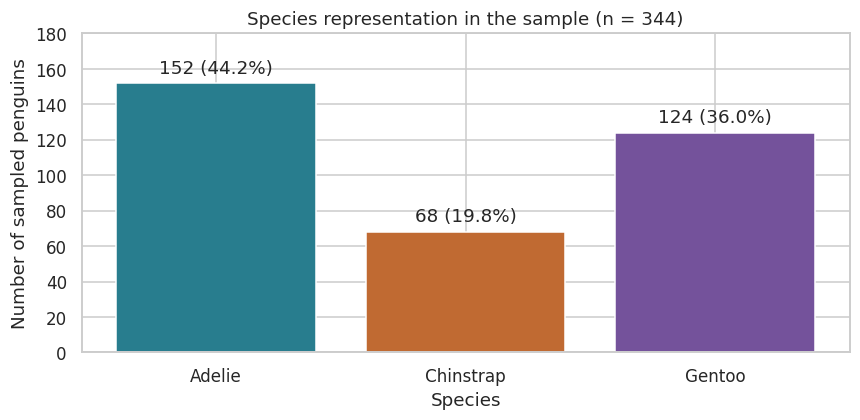

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


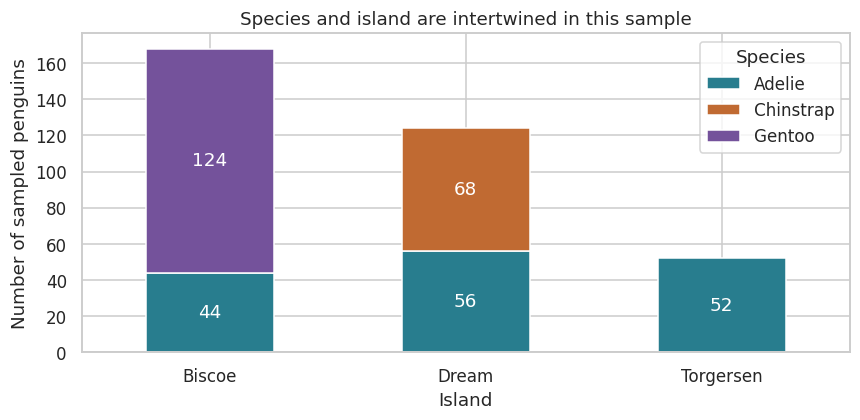

In [4]:
counts = df.species.value_counts().reindex(ORDER)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(ORDER, counts, color=[COLORS[s] for s in ORDER])
ax.bar_label(bars, labels=[f'{n} ({n/len(df):.1%})' for n in counts], padding=4)
ax.set(xlabel='Species', ylabel='Number of sampled penguins', ylim=(0, 180),
       title='Species representation in the sample (n = 344)')
savefig('01_species_counts')
island = pd.crosstab(df.island, df.species).reindex(columns=ORDER)
island.to_csv(ROOT / 'tables/island_species_counts.csv')
display(island)
fig, ax = plt.subplots(figsize=(8, 4))
island.plot.bar(stacked=True, ax=ax, color=[COLORS[s] for s in ORDER], rot=0)
ax.set(xlabel='Island', ylabel='Number of sampled penguins',
       title='Species and island are intertwined in this sample')
ax.legend(title='Species', loc='upper right')
for container in ax.containers:
    ax.bar_label(container, label_type='center', labels=[str(int(v)) if v else '' for v in container.datavalues], color='white')
savefig('02_island_species')

Adelie has the largest sample, while Chinstrap has the smallest. Gentoo occurs only on Biscoe and Chinstrap only on Dream in these records. Thus, a pooled island comparison would mix geographic and species differences.

## 4 Numeric distributions
Shared physical units are retained. Histograms show counts using 18 bins; bin choice changes visual detail, so interpretations also use exact descriptive statistics.

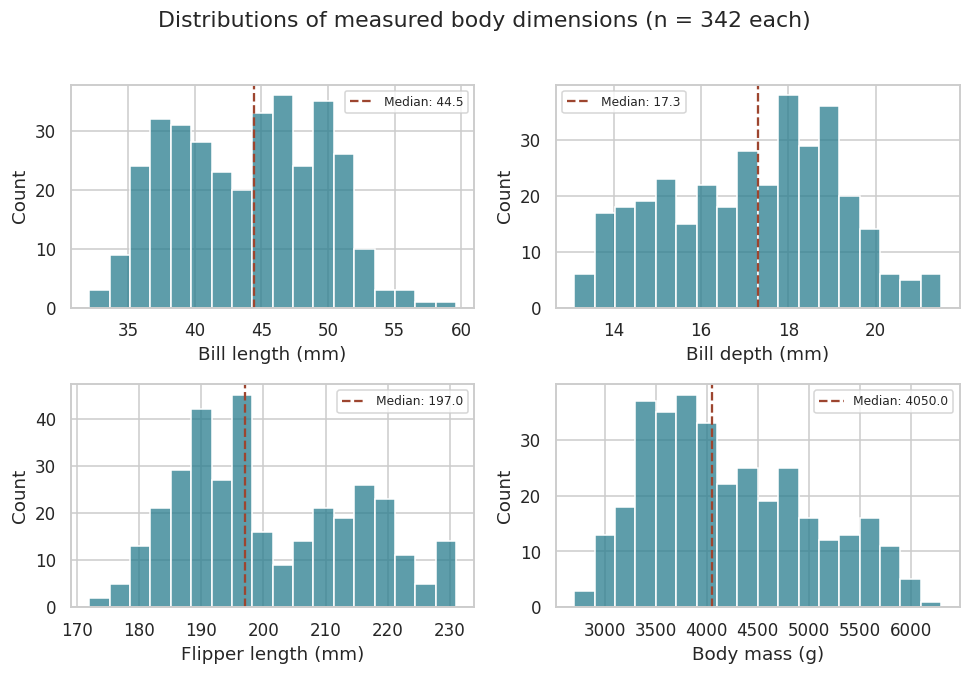

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for col, label, ax in zip(NUM, LABELS, axes.flat):
    sns.histplot(data=df, x=col, bins=18, color='#287D8E', ax=ax)
    ax.axvline(df[col].median(), color='#9D452F', linestyle='--', label=f'Median: {df[col].median():.1f}')
    ax.set(xlabel=label, ylabel='Count')
    ax.legend(fontsize=8)
fig.suptitle('Distributions of measured body dimensions (n = 342 each)', y=1.02)
savefig('03_distributions')

The flipper-length and mass distributions reflect a mixture of species. A single overall mean should not be treated as a typical value for every species. The observed ranges are not automatic error thresholds.

## 5 Body mass by species and sex
Box centers show medians, boxes show the middle 50%, whiskers use 1.5 times IQR, and isolated markers are potential extremes. An IQR flag is not proof of a recording error.

count     mean  median     std
species   sex                                   
Adelie    female     73  3368.84  3400.0  269.38
          male       73  4043.49  4000.0  346.81
Chinstrap female     34  3527.21  3550.0  285.33
          male       34  3938.97  3950.0  362.14
Gentoo    female     58  4679.74  4700.0  281.58
          male       61  5484.84  5500.0  313.16

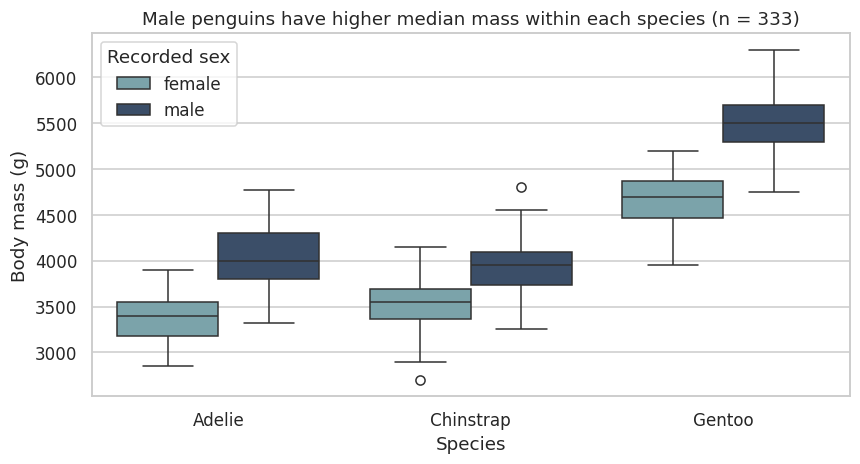

In [6]:
sex_summary = sex_data.groupby(['species','sex']).body_mass_g.agg(['count','mean','median','std'])
sex_summary.to_csv(ROOT / 'tables/species_sex_mass.csv')
display(sex_summary.round(2))
fig, ax = plt.subplots(figsize=(8, 4.4))
sns.boxplot(data=sex_data, x='species', y='body_mass_g', hue='sex', order=ORDER,
            hue_order=['female','male'], palette=['#73A9B2','#334D70'], ax=ax)
ax.set(xlabel='Species', ylabel='Body mass (g)', title='Male penguins have higher median mass within each species (n = 333)')
ax.legend(title='Recorded sex')
savefig('04_mass_species_sex')

Within each species, recorded males have greater average body mass. This is consistent with sex-related size differences, but this observational analysis does not identify their biological causes. Eleven missing sex entries are excluded only from sex-specific comparisons.

## 6 Relationships and correlation
Pearson correlation measures linear association. Spearman correlation provides a rank-based sensitivity check. All four measurement variables are observed for the same 342 rows here; categorical codes and year are excluded.

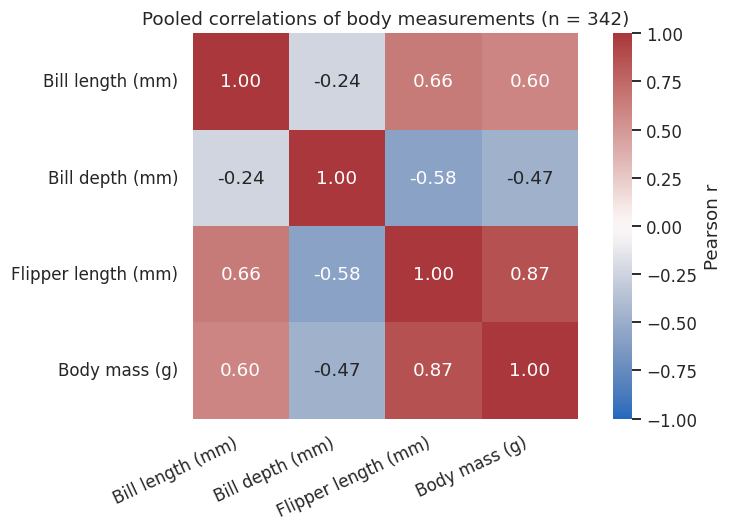

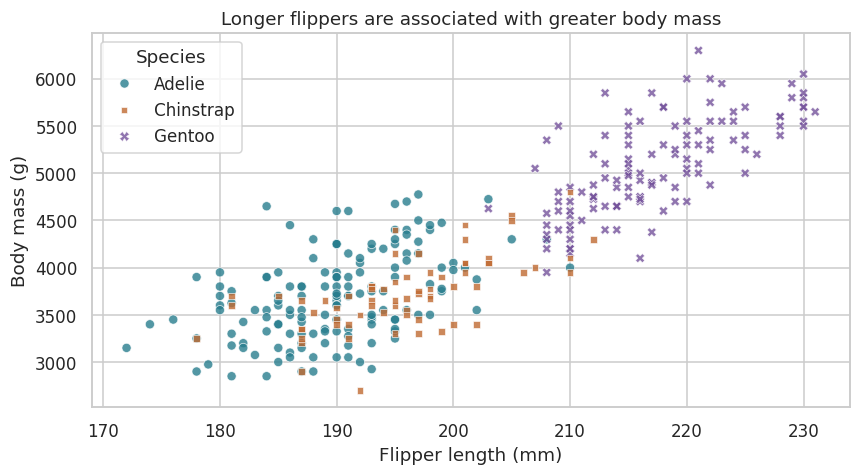

,group,n,flipper_mass_r,depth_mass_r,flipper_mass_spearman
0,Pooled,342,0.871,-0.472,0.840
1,Adelie,151,0.468,0.576,0.475
2,Chinstrap,68,0.642,0.604,0.670
3,Gentoo,123,0.703,0.719,0.717


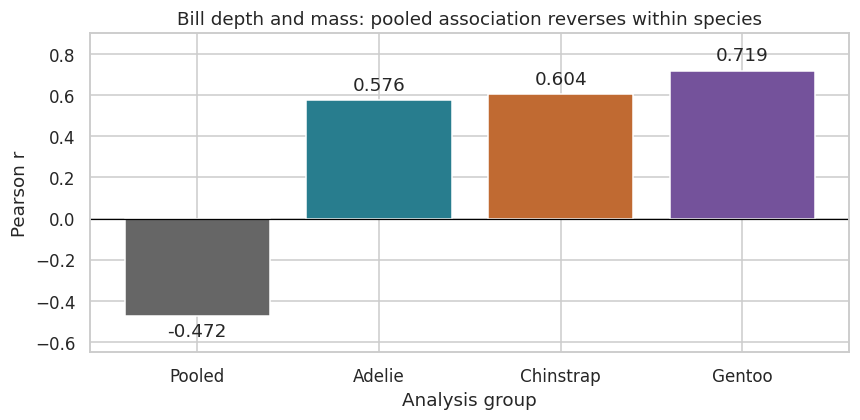

In [7]:
pearson = measurements[NUM].corr(method='pearson')
spearman = measurements[NUM].corr(method='spearman')
pearson.to_csv(ROOT / 'tables/pearson_correlations.csv')
spearman.to_csv(ROOT / 'tables/spearman_correlations.csv')
fig, ax = plt.subplots(figsize=(7.6, 5))
sns.heatmap(pearson.set_axis(LABELS).set_axis(LABELS, axis=1), annot=True, fmt='.2f',
            cmap='vlag', vmin=-1, vmax=1, center=0, square=True,
            cbar_kws={'label':'Pearson r'}, ax=ax)
ax.set_title('Pooled correlations of body measurements (n = 342)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
savefig('05_correlation')
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(data=measurements, x='flipper_length_mm', y='body_mass_g',
                hue='species', style='species', hue_order=ORDER, palette=COLORS, alpha=.8, ax=ax)
ax.set(xlabel='Flipper length (mm)', ylabel='Body mass (g)',
       title='Longer flippers are associated with greater body mass')
ax.legend(title='Species')
savefig('06_flipper_mass')
rows=[]
for name, group in [('Pooled', measurements)] + list(measurements.groupby('species')):
    rows.append({'group': name, 'n':len(group),
        'flipper_mass_r':group.flipper_length_mm.corr(group.body_mass_g),
        'depth_mass_r':group.bill_depth_mm.corr(group.body_mass_g),
        'flipper_mass_spearman':group.flipper_length_mm.corr(group.body_mass_g, method='spearman')})
corr_groups = pd.DataFrame(rows)
corr_groups.to_csv(ROOT / 'tables/group_correlations.csv', index=False)
display(corr_groups.round(3))
fig, ax = plt.subplots(figsize=(8, 4))
bars=ax.bar(corr_groups.group, corr_groups.depth_mass_r, color=['#666666']+[COLORS[s] for s in corr_groups.group[1:]])
ax.bar_label(bars, fmt='%.3f', padding=4)
ax.axhline(0, color='black', linewidth=.8)
ax.set(ylim=(-.65,.9), xlabel='Analysis group', ylabel='Pearson r',
       title='Bill depth and mass: pooled association reverses within species')
savefig('07_correlation_reversal')

The pooled bill-depth–mass association is negative, but all within-species associations are positive. Gentoo combines high mass with relatively shallow bills, shifting the pooled relationship. This aggregation reversal shows why species must be considered. Correlation does not demonstrate causation, and sex may also contribute to within-species associations.

## 7 Unusual observations and sensitivity
Screen each measurement separately within species using Q1 − 1.5 × IQR and Q3 + 1.5 × IQR. Flagged observations remain in the main analysis. A temporary exclusion is used only to assess the stability of species mean mass.

In [8]:
flags = pd.DataFrame(False, index=measurements.index, columns=NUM)
thresholds=[]
for species, group in measurements.groupby('species'):
    for col in NUM:
        q1, q3 = group[col].quantile([.25,.75])
        lower, upper = q1-1.5*(q3-q1), q3+1.5*(q3-q1)
        flags.loc[group.index,col] = (group[col] < lower) | (group[col] > upper)
        thresholds.append([species,col,lower,upper,int(flags.loc[group.index,col].sum())])
thresholds = pd.DataFrame(thresholds, columns=['species','variable','lower','upper','flagged_count'])
thresholds.to_csv(ROOT / 'tables/iqr_thresholds.csv',index=False)
flagged = measurements.loc[flags.any(axis=1)].copy()
flagged.insert(0,'source_row',flagged.index+1)
flagged['flagged_fields'] = flags.loc[flagged.index].apply(lambda r: ', '.join(r.index[r]), axis=1)
flagged.to_csv(ROOT / 'tables/flagged_observations.csv',index=False)
display(flagged)
sensitivity = pd.concat([measurements.groupby('species').body_mass_g.mean().rename('all_mean_g'),
    measurements.loc[~flags.any(axis=1)].groupby('species').body_mass_g.mean().rename('without_flagged_mean_g')],axis=1)
sensitivity['change_g'] = sensitivity.without_flagged_mean_g-sensitivity.all_mean_g
sensitivity.to_csv(ROOT / 'tables/outlier_sensitivity.csv')
display(sensitivity.round(2))
print('Flagged unique records:', len(flagged))

Flagged unique records: 6


,source_row,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,flagged_fields
19,20,Adelie,Torgersen,46.0,21.5,194.0,4200.0,male,2007,bill_depth_mm
28,29,Adelie,Biscoe,37.9,18.6,172.0,3150.0,female,2007,flipper_length_mm
129,130,Adelie,Torgersen,44.1,18.0,210.0,4000.0,male,2009,flipper_length_mm
185,186,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,male,2007,bill_length_mm
313,314,Chinstrap,Dream,52.0,20.7,210.0,4800.0,male,2008,body_mass_g
314,315,Chinstrap,Dream,46.9,16.6,192.0,2700.0,female,2008,body_mass_g


,all_mean_g,without_flagged_mean_g,change_g
species,,,
Adelie,3700.66,3698.99,-1.68
Chinstrap,3733.09,3732.58,-0.51
Gentoo,5076.02,5068.03,-7.98


## 8 Missingness sensitivity and annual summaries
Compare available-mass means with means from fully complete records. Annual means are descriptive snapshots of sampled birds, not longitudinal growth or evidence of climate change.

,available_mass_mean_g,complete_case_mean_g,change_g
species,,,
Adelie,3700.66,3706.16,5.50
Chinstrap,3733.09,3733.09,0.00
Gentoo,5076.02,5092.44,16.42


,species,year,count,mean,median
0,Adelie,2007,49,3696.43,3650.0
1,Adelie,2008,50,3742.00,3700.0
2,Adelie,2009,52,3664.90,3600.0
3,Chinstrap,2007,26,3694.23,3700.0
4,Chinstrap,2008,18,3800.00,3750.0
5,Chinstrap,2009,24,3725.00,3675.0
6,Gentoo,2007,34,5070.59,5050.0
7,Gentoo,2008,46,5019.57,5000.0
8,Gentoo,2009,43,5140.70,5000.0


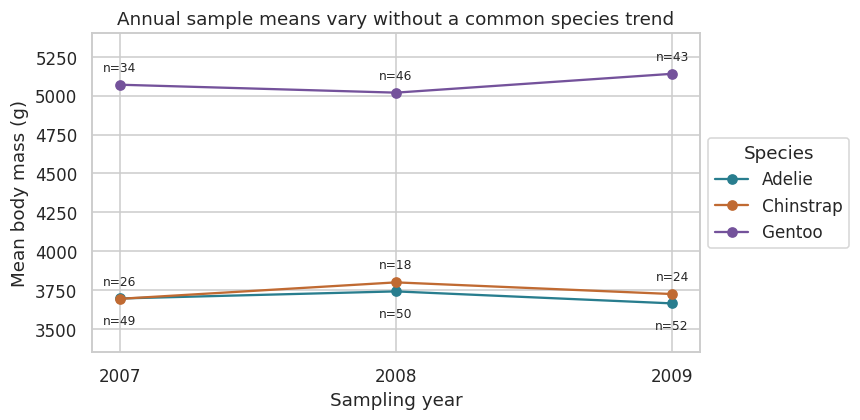

In [9]:
missing_sensitivity = pd.concat([df.groupby('species').body_mass_g.mean().rename('available_mass_mean_g'),
    df.dropna().groupby('species').body_mass_g.mean().rename('complete_case_mean_g')],axis=1)
missing_sensitivity['change_g'] = missing_sensitivity.complete_case_mean_g-missing_sensitivity.available_mass_mean_g
missing_sensitivity.to_csv(ROOT / 'tables/missingness_sensitivity.csv')
display(missing_sensitivity.round(2))
annual = df.groupby(['species','year']).body_mass_g.agg(['count','mean','median']).reset_index()
annual.to_csv(ROOT / 'tables/annual_mass_summary.csv',index=False)
display(annual.round(2))
fig, ax = plt.subplots(figsize=(8, 4))
for species in ORDER:
    g=annual[annual.species==species]
    ax.plot(g.year,g['mean'],marker='o',label=species,color=COLORS[species])
    for _, row in g.iterrows():
        ax.annotate(f'n={int(row["count"])}',(row.year,row['mean']),xytext=(0,-17 if species == 'Adelie' else 9),textcoords='offset points',ha='center',fontsize=8)
ax.set(xlabel='Sampling year',ylabel='Mean body mass (g)',xticks=[2007,2008,2009],
       ylim=(3350,5400), title='Annual sample means vary without a common species trend')
ax.legend(title='Species',loc='center left',bbox_to_anchor=(1, .5))
savefig('08_annual_mass')

## 9 Conclusions and limitations
Species and sex are important grouping variables. Flipper length and body mass are strongly associated, while bill depth illustrates the danger of pooled correlations. Island comparisons are confounded by sampled species composition. No values were imputed or outliers deleted.

Missingness may be selective; small changes in observed means do not prove missing data are random. These 344 records cover three islands and three years, not all Antarctic penguins. No formal hypothesis tests, prediction model or causal claims are made. Future work could evaluate species- and sex-adjusted regression with explicit assumptions and held-out validation.

References: Horst, Hill and Gorman, palmerpenguins (2020), https://doi.org/10.5281/zenodo.3960218; Gorman, Williams and Fraser (2014), https://doi.org/10.1371/journal.pone.0090081; package documentation https://allisonhorst.github.io/palmerpenguins/.

In [10]:
versions = {'python':platform.python_version(),'pandas':pd.__version__,
            'numpy':np.__version__,'matplotlib':plt.matplotlib.__version__,'seaborn':sns.__version__}
(ROOT / 'tables/software_versions.json').write_text(json.dumps(versions,indent=2))
print(versions)
print('Analysis complete. Figures and tables saved locally; original CSV unchanged.')

{'python': '3.12.14', 'pandas': '2.2.3', 'numpy': '2.3.5', 'matplotlib': '3.10.8', 'seaborn': '0.13.2'}
Analysis complete. Figures and tables saved locally; original CSV unchanged.
